In [24]:
#switch to R for cvs import and analysis
#First row of cvs is title, skipped when importing
total_costby_statedisaster<- read.csv("yale-capstone-project/data/state-cost-data.csv",skip=1)
print(total_costby_statedisaster)

   state  drought flooding  freeze severe.storm tropical.cyclone wildfire
1     AK      0.0      0.0     0.0          0.0              0.0   2344.4
2     AL   6938.1    137.7   152.4      14669.7          27197.6    733.3
3     AR   6893.5   4703.9   298.6      11951.6            720.1      0.0
4     AZ   1607.2   1922.4     0.0       5472.0              0.0   1356.1
5     CA  16558.0  19214.9 15491.0       3533.5              0.0 100093.8
6     CO   7342.7   2082.1   105.0      33317.9              0.0   7231.5
7     CT     13.3    612.2    42.0        908.9           6006.8      0.0
8     DC      0.0      0.0     0.0          0.0              0.0      0.0
9     DE    887.0     34.7    12.6        286.2           1034.8      0.0
10    FL   1531.8   2944.1 13921.4       6645.3         422701.6    306.2
11    GA   8401.7   1418.6  1315.0      13120.6          33040.8    294.8
12    GU      0.0      0.0     0.0          0.0           4420.0      0.0
13    HI      0.0      0.0     0.0    

In [15]:
#Cencus regions 
# Northeast 1=CT, ME, MA, NH, RI, VT, NJ, NY, PA
# Midwest 2=IL, IN, MI, OH, WI, IA, NE, KS, ND, SD, MN, MO
# South 3= DE, DC, FL, GA, MD, NC, SC, VA, WV, AL, KY, MS, TN, AR, LA, OK, TX
#West 4= AZ, NV, CO, ID, MT, NM, UT, WY AK, CA, HI, OR, WA

In [25]:
library(dplyr)
#remove GU, PR, US, and VI
state_disastercost_clean <- total_costby_statedisaster %>% 
slice(-c(12, 41,  47, 50))

print(state_disastercost_clean)

   state drought flooding  freeze severe.storm tropical.cyclone wildfire
1     AK     0.0      0.0     0.0          0.0              0.0   2344.4
2     AL  6938.1    137.7   152.4      14669.7          27197.6    733.3
3     AR  6893.5   4703.9   298.6      11951.6            720.1      0.0
4     AZ  1607.2   1922.4     0.0       5472.0              0.0   1356.1
5     CA 16558.0  19214.9 15491.0       3533.5              0.0 100093.8
6     CO  7342.7   2082.1   105.0      33317.9              0.0   7231.5
7     CT    13.3    612.2    42.0        908.9           6006.8      0.0
8     DC     0.0      0.0     0.0          0.0              0.0      0.0
9     DE   887.0     34.7    12.6        286.2           1034.8      0.0
10    FL  1531.8   2944.1 13921.4       6645.3         422701.6    306.2
11    GA  8401.7   1418.6  1315.0      13120.6          33040.8    294.8
12    HI     0.0      0.0     0.0          0.0           6913.0   5665.0
13    IA 16507.2  24791.5    77.6      23085.2     

In [26]:
# adding census regions
# Northeast 1=CT, ME, MA, NH, RI, VT, NJ, NY, PA
# Midwest 2=IL, IN, MI, OH, WI, IA, NE, KS, ND, SD, MN, MO
# South 3= DE, DC, FL, GA, MD, NC, SC, VA, WV, AL, KY, MS, TN, AR, LA, OK, TX
#West 4= AZ, NV, CO, ID, MT, NM, UT, WY AK, CA, HI, OR, WA

region_statedisaster<- state_disastercost_clean %>%
    mutate (census_region = case_when(
    state %in% c("CT", "ME", "MA", "NH", "RI", "VT", "NJ", "NY", "PA") ~ "Region_1",
    state %in% c("IL", "IN", "MI", "OH", "WI", "IA", "NE", "KS", "ND", "SD", "MN", "MO") ~ "Region_2",
    state %in% c("DE", "DC", "FL", "GA", "MD", "NC", "SC", "VA", "WV", "AL", "KY", "MS", "TN", "AR", "LA", "OK", "TX") ~ "Region_3",
    state %in% c("AZ", "NV", "CO", "ID", "MT", "NM", "UT", "WY", "AK", "CA", "HI", "OR", "WA") ~ "Region_4",
    TRUE ~ "Other"))

head(region_statedisaster)

,state,drought,flooding,freeze,severe.storm,tropical.cyclone,wildfire,winter.storm,census_region
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AK,0.0,0.0,0.0,0.0,0.0,2344.4,0.0,Region_4
2,AL,6938.1,137.7,152.4,14669.7,27197.6,733.3,2432.0,Region_3
3,AR,6893.5,4703.9,298.6,11951.6,720.1,0.0,1360.4,Region_3
4,AZ,1607.2,1922.4,0.0,5472.0,0.0,1356.1,0.0,Region_4
5,CA,16558.0,19214.9,15491.0,3533.5,0.0,100093.8,0.0,Region_4
6,CO,7342.7,2082.1,105.0,33317.9,0.0,7231.5,418.9,Region_4


In [32]:
#aggregate the data so data is only displayed by regions
region_statedisaster_grouped<- region_statedisaster %>%
    group_by(census_region) %>%
    summarise(across(where(is.numeric), sum))

print(region_statedisaster_grouped)

# A tibble: 4 × 8
  census_region drought flooding freeze severe.storm tropical.cyclone wildfire
  <chr>           <dbl>    <dbl>  <dbl>        <dbl>            <dbl>    <dbl>
1 Region_1        3823.    8863.   328.       21427.          146904.       0 
2 Region_2      164813.   98877.  2275.      190740.            6914.     281 
3 Region_3      139589.   65600. 18847.      255486.         1230109.    6816.
4 Region_4       59583.   29616. 15894.       46391.            7218.  140948.
# ℹ 1 more variable: winter.storm <dbl>


In [41]:
#pivot table so we have disaster type as rows and region as columns 
library(tidyverse)
distcost_long <- region_statedisaster_grouped %>%
  pivot_longer(
  cols = drought:winter.storm, # the columns we want to pivot
  names_to = "DisasterType", # the new variable where the names of columns will be assigned 
  values_to = "TotalCost" # the new variable where the values will be assigned  
)
distcost_long

distcost_long_gr <- distcost_long %>%
   group_by(census_region) %>%
    summarise(across(where(is.numeric), sum))

distcost_long_gr

census_region,DisasterType,TotalCost
<chr>,<chr>,<dbl>
Region_1,drought,3823.3
Region_1,flooding,8863.1
Region_1,freeze,327.6
Region_1,severe.storm,21426.9
Region_1,tropical.cyclone,146903.8
Region_1,wildfire,0.0
Region_1,winter.storm,31624.6
Region_2,drought,164813.4
Region_2,flooding,98877.4


census_region,TotalCost
<chr>,<dbl>
Region_1,212969.3
Region_2,471683.3
Region_3,1778453.4
Region_4,302674.2


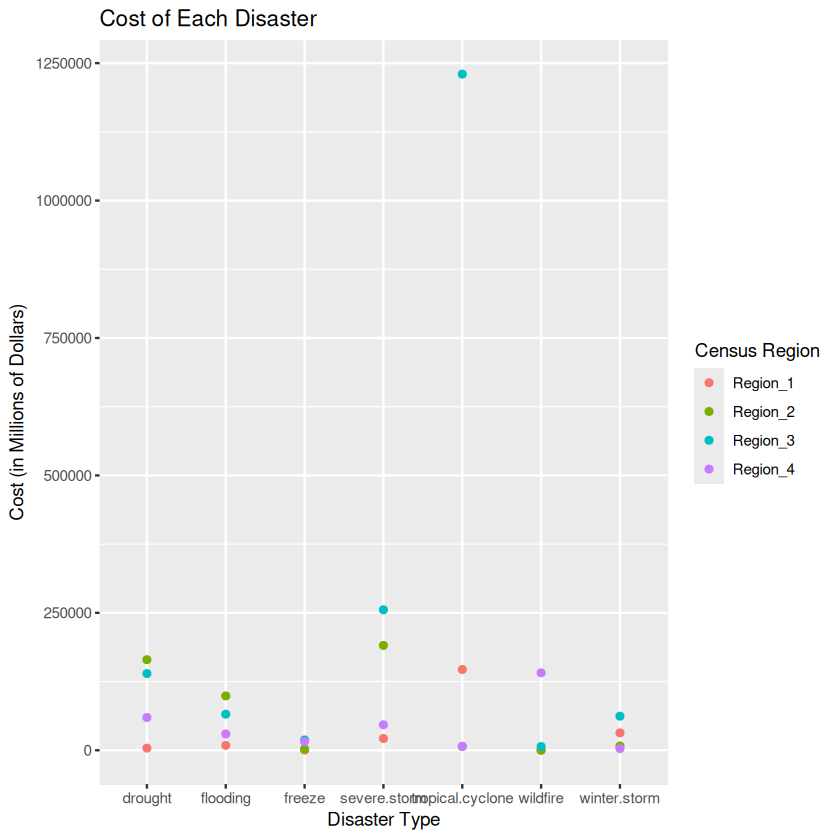

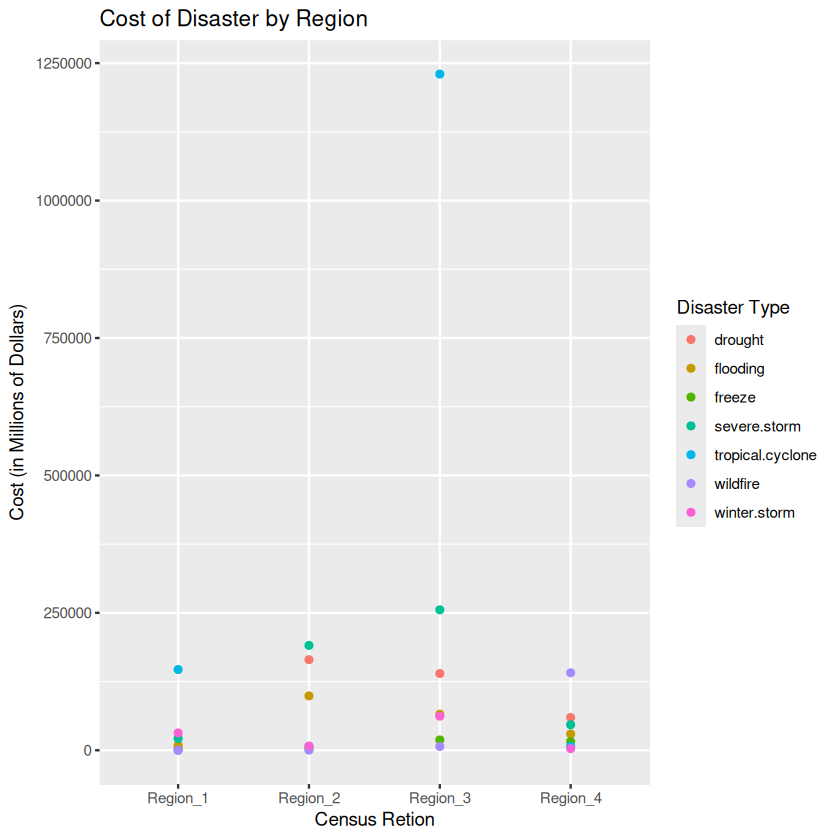

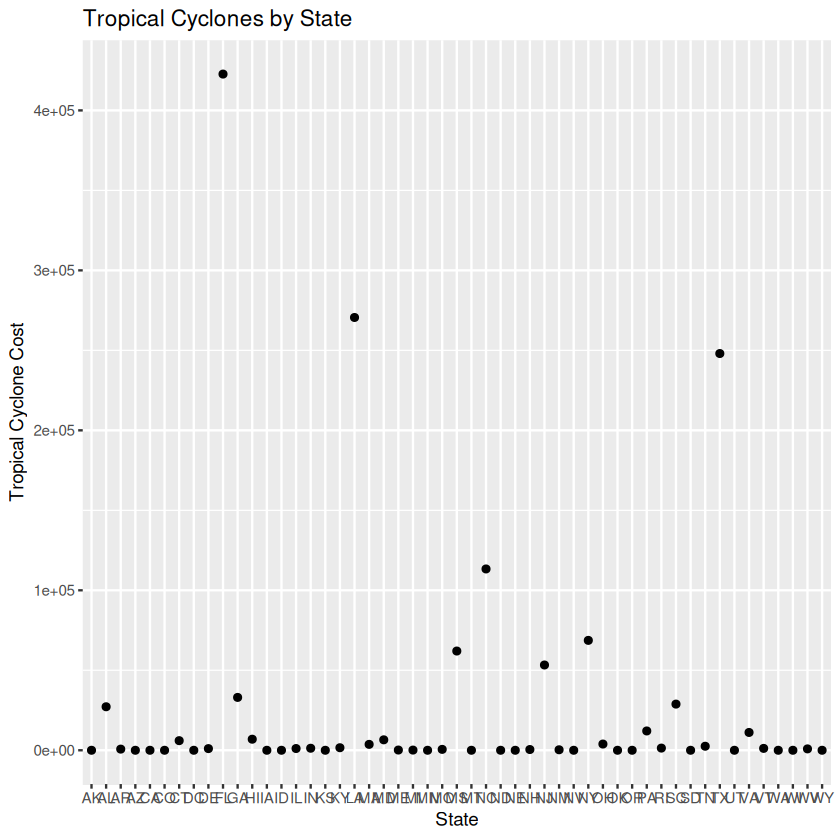

In [56]:
#Let's see what these look like
library(ggplot2)
ggplot(distcost_long, aes(x = DisasterType, y = TotalCost, color = census_region)) +
    geom_point() +
    labs(title = "Cost of Each Disaster",
         x = "Disaster Type",
         y = "Cost (in Millions of Dollars)",
color = "Census Region"
        )

ggplot(distcost_long, aes(x = census_region, y = TotalCost, color = DisasterType)) +
    geom_point() +
    labs(title = "Cost of Disaster by Region",
         x = "Census Retion",
         y = "Cost (in Millions of Dollars)",
color = "Disaster Type"
        )

ggplot(state_disastercost_clean, aes(x = state, y = tropical.cyclone)) +
    geom_point() +
    labs(title = "Tropical Cyclones by State",
         x = "State",
         y = "Tropical Cyclone Cost"
        ) 